# Predictive Modeling of Life Satisfaction Among Women in Canada

## Project overview

This notebook is part of a Major Research Project using the 2022 Canadian Community Health Survey Public Use Microdata File. It develops and compares classification models for identifying low life satisfaction among women in Canada.

The main analysis uses the broader cleaned women-focused dataset:

`../data/processed/cchs_2022_women_eda_dataset.csv`

Employment-specific variables `LBFDVPFT` and `LBFDGHPW` are excluded because they apply only to employed respondents. The broader labour-force variable `LBFDGWSS` is retained.

The binary target is:

- `LowLifeSatisfaction = 1` when `LSMDVSWL` is 4 or 5
- `LowLifeSatisfaction = 0` when `LSMDVSWL` is 1, 2, or 3

The notebook compares a baseline classifier, Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and tuned tree-based models. Because the positive class is uncommon, evaluation emphasizes recall, F1-score, ROC-AUC, PR-AUC, balanced accuracy, and interpretability rather than accuracy alone.


## 1. Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42

DATA_DIR = Path("../data/processed")
TABLE_DIR = Path("../outputs/tables")
FIGURE_DIR = Path("../outputs/figures")

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MAIN_DATA_FILE = DATA_DIR / "cchs_2022_women_eda_dataset.csv"
EMPLOYED_DATA_FILE = DATA_DIR / "cchs_2022_women_model_dataset.csv"

OUTCOME_COL = "LSMDVSWL"
TARGET_COL = "LowLifeSatisfaction"

PREDICTORS = [
    "DHHGAGE",
    "DHHDGHSZ",
    "GEOGPRV",
    "SDCDGIMM",
    "SDCDVFLA",
    "INCDGHH",
    "EDDVH3",
    "FSCDVHF2",
    "LBFDGWSS",
    "WDMDGDIF",
    "CCCDGSKL",
]


## 2. Load data and check for survey weights

The processed datasets are checked for columns whose names suggest a final survey weight. A candidate is not used unless it can be confirmed using the CCHS documentation. If a candidate is found, the notebook stops before model fitting.


In [2]:
if not MAIN_DATA_FILE.exists():
    raise FileNotFoundError(f"Main dataset not found: {MAIN_DATA_FILE}")

df = pd.read_csv(MAIN_DATA_FILE)

def find_weight_candidates(columns):
    terms = (
        "weight", "wgt", "surveywt", "survey_weight",
        "finalwt", "final_weight", "personwt",
        "person_weight", "bootstrap"
    )
    return [
        column for column in columns
        if any(term in column.lower() for term in terms)
    ]

main_weight_candidates = find_weight_candidates(df.columns)

if EMPLOYED_DATA_FILE.exists():
    employed_columns = pd.read_csv(
        EMPLOYED_DATA_FILE,
        nrows=0,
    ).columns
    employed_weight_candidates = find_weight_candidates(
        employed_columns
    )
else:
    employed_weight_candidates = []

print("Main dataset shape:", df.shape)
print(
    "Possible weight columns in main dataset:",
    main_weight_candidates,
)
print(
    "Possible weight columns in employed-women dataset:",
    employed_weight_candidates,
)

if main_weight_candidates:
    for column in main_weight_candidates:
        print(f"\nMain dataset candidate: {column}")
        print(df[column].describe())

if employed_weight_candidates:
    employed_weight_data = pd.read_csv(
        EMPLOYED_DATA_FILE,
        usecols=employed_weight_candidates,
    )
    for column in employed_weight_candidates:
        print(
            f"\nEmployed-women dataset candidate: {column}"
        )
        print(employed_weight_data[column].describe())

if main_weight_candidates or employed_weight_candidates:
    raise RuntimeError(
        "Potential survey-weight variable found. Confirm it in the "
        "CCHS documentation before continuing."
    )

print("\nNo identifiable final survey-weight variable was found.")


Main dataset shape: (52884, 14)
Possible weight columns in main dataset: []
Possible weight columns in employed-women dataset: []

No identifiable final survey-weight variable was found.


### Survey-weight limitation

No identifiable final survey-weight variable is available in the processed datasets. The predictive models are therefore unweighted. Results describe associations and predictive performance within the analytical sample and should not be interpreted as nationally representative estimates for all women in Canada.


## 3. Prepare the analytical sample


In [3]:
required_columns = [OUTCOME_COL, *PREDICTORS]
missing_columns = [
    column for column in required_columns
    if column not in df.columns
]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

model_df = df.copy()
model_df[OUTCOME_COL] = pd.to_numeric(
    model_df[OUTCOME_COL],
    errors="coerce"
)

# Retain valid life-satisfaction responses and create the binary target.
model_df = model_df[
    model_df[OUTCOME_COL].isin([1, 2, 3, 4, 5])
].copy()

model_df[TARGET_COL] = (
    model_df[OUTCOME_COL].isin([4, 5])
).astype(int)

model_df = model_df[PREDICTORS + [TARGET_COL]].copy()

# Remove validated non-response code 9 from these two variables.
model_df = model_df[
    (model_df["DHHDGHSZ"] != 9)
    & (model_df["LBFDGWSS"] != 9)
].dropna().copy()

class_summary = (
    model_df[TARGET_COL]
    .value_counts()
    .sort_index()
    .rename_axis("Target")
    .reset_index(name="Count")
)
class_summary["Percentage"] = (
    class_summary["Count"] / len(model_df) * 100
).round(2)

print("Final modeling shape:", model_df.shape)
display(class_summary)


Final modeling shape: (52543, 12)


,Target,Count,Percentage
0,0,49228,93.69
1,1,3315,6.31


## 4. Train-test split and preprocessing

All predictors are treated as categorical CCHS codes. The test set is held out for final evaluation. One-hot encoding is fitted on the training data only.


In [4]:
X = model_df[PREDICTORS].astype(str)
y = model_df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            PREDICTORS,
        )
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

X_train_dense = (
    X_train_encoded.toarray()
    if hasattr(X_train_encoded, "toarray")
    else X_train_encoded
)
X_test_dense = (
    X_test_encoded.toarray()
    if hasattr(X_test_encoded, "toarray")
    else X_test_encoded
)

feature_names = [
    name.replace("cat__", "")
    for name in preprocessor.get_feature_names_out()
]

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Encoded features:", len(feature_names))
print(
    "Training positive-class percentage:",
    round(y_train.mean() * 100, 2),
)
print(
    "Test positive-class percentage:",
    round(y_test.mean() * 100, 2),
)


Training rows: 42034
Test rows: 10509
Encoded features: 39
Training positive-class percentage: 6.31
Test positive-class percentage: 6.31


## 5. Reusable evaluation and plotting functions


In [5]:
def calculate_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "Weighted F1-score": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(
            y_true, y_proba
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true, y_pred
        ),
    }


def evaluate_model(model, X_eval, y_true, model_name):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    result = {"Model": model_name}
    result.update(calculate_metrics(y_true, y_pred, y_proba))
    return result, y_pred, y_proba


def save_confusion_matrix(
    y_true,
    y_pred,
    title,
    filename,
):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    display_obj = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Low", "Low"],
    )
    fig, ax = plt.subplots(figsize=(6, 5))
    display_obj.plot(ax=ax, values_format="d")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


def create_feature_importance_table(
    model,
    names,
):
    table = pd.DataFrame({
        "Feature": names,
        "Importance": model.feature_importances_,
    })
    return table.sort_values(
        "Importance",
        ascending=False,
    ).reset_index(drop=True)


def save_feature_importance_plot(
    importance_table,
    title,
    filename,
    top_n=15,
):
    plot_data = (
        importance_table.head(top_n)
        .sort_values("Importance")
    )
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(
        plot_data["Feature"],
        plot_data["Importance"],
    )
    ax.set_title(title)
    ax.set_xlabel("Feature importance")
    ax.set_ylabel("Feature")
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 6. Fit benchmark models


In [6]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE,
)

decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=50,
    random_state=RANDOM_STATE,
)

baseline_model.fit(X_train_encoded, y_train)
logistic_model.fit(X_train_encoded, y_train)
decision_tree_model.fit(X_train_encoded, y_train)
random_forest_model.fit(X_train_encoded, y_train)

gb_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_train,
)
gradient_boosting_model.fit(
    X_train_dense,
    y_train,
    sample_weight=gb_sample_weight,
)

print("Benchmark models fitted successfully.")


Benchmark models fitted successfully.


## 7. Tune Decision Tree and Random Forest

Hyperparameters are selected using stratified three-fold cross-validation and `average_precision` (PR-AUC), which is appropriate for the imbalanced positive class.


In [7]:
tuning_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

dt_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    param_grid={
        "max_depth": [3, 4, 5, 6, 8, 10],
        "min_samples_split": [50, 100, 250, 500],
        "min_samples_leaf": [50, 100, 250, 500],
    },
    scoring="average_precision",
    cv=tuning_cv,
    n_jobs=-1,
)

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_distributions={
        "n_estimators": [200, 300, 500],
        "max_depth": [5, 8, 10, 12, None],
        "min_samples_split": [50, 100, 250],
        "min_samples_leaf": [25, 50, 100, 250],
        "max_features": ["sqrt", "log2", None],
    },
    n_iter=20,
    scoring="average_precision",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

dt_grid_search.fit(X_train_encoded, y_train)
rf_random_search.fit(X_train_encoded, y_train)

tuned_decision_tree_model = dt_grid_search.best_estimator_
tuned_random_forest_model = rf_random_search.best_estimator_

pd.DataFrame(dt_grid_search.cv_results_).to_csv(
    TABLE_DIR / "decision_tree_tuning_results.csv",
    index=False,
)
pd.DataFrame(rf_random_search.cv_results_).to_csv(
    TABLE_DIR / "random_forest_tuning_results.csv",
    index=False,
)

print("Best Decision Tree parameters:")
print(dt_grid_search.best_params_)
print("Best CV PR-AUC:", round(dt_grid_search.best_score_, 4))

print("\nBest Random Forest parameters:")
print(rf_random_search.best_params_)
print("Best CV PR-AUC:", round(rf_random_search.best_score_, 4))


Best Decision Tree parameters:
{'max_depth': 8, 'min_samples_leaf': 250, 'min_samples_split': 50}
Best CV PR-AUC: 0.1852

Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 250, 'min_samples_leaf': 25, 'max_features': 'sqrt', 'max_depth': 5}
Best CV PR-AUC: 0.2049


## 8. Final held-out test evaluation


In [8]:
model_registry = {
    "Baseline Model": (
        baseline_model,
        X_test_encoded,
    ),
    "Logistic Regression": (
        logistic_model,
        X_test_encoded,
    ),
    "Decision Tree": (
        decision_tree_model,
        X_test_encoded,
    ),
    "Tuned Decision Tree": (
        tuned_decision_tree_model,
        X_test_encoded,
    ),
    "Random Forest": (
        random_forest_model,
        X_test_encoded,
    ),
    "Tuned Random Forest": (
        tuned_random_forest_model,
        X_test_encoded,
    ),
    "Gradient Boosting": (
        gradient_boosting_model,
        X_test_dense,
    ),
}

performance_rows = []
test_predictions = {}
test_probabilities = {}

for model_name, (model, X_eval) in model_registry.items():
    result, predictions, probabilities = evaluate_model(
        model,
        X_eval,
        y_test,
        model_name,
    )
    performance_rows.append(result)
    test_predictions[model_name] = predictions
    test_probabilities[model_name] = probabilities

model_performance = pd.DataFrame(
    performance_rows
).round(3)

model_performance.to_csv(
    TABLE_DIR / "model_performance_comparison_extended.csv",
    index=False,
)

display(model_performance)


,Model,Accuracy,Precision,Recall,F1-score,Weighted F1-score,ROC-AUC,PR-AUC,Balanced Accuracy
0,Baseline Model,0.937,0.000,0.000,0.000,0.906,0.500,0.063,0.500
1,Logistic Regression,0.686,0.123,0.650,0.207,0.766,0.731,0.197,0.669
2,Decision Tree,0.695,0.123,0.627,0.206,0.773,0.717,0.164,0.664
3,Tuned Decision Tree,0.688,0.121,0.627,0.203,0.768,0.723,0.185,0.660
4,Random Forest,0.677,0.121,0.661,0.205,0.760,0.733,0.201,0.669
5,Tuned Random Forest,0.636,0.112,0.692,0.193,0.729,0.731,0.201,0.662
6,Gradient Boosting,0.685,0.122,0.643,0.205,0.766,0.733,0.204,0.665


### Model comparison

All non-baseline models identify substantially more low-life-satisfaction cases than the majority-class baseline. Predictive performance is moderate, and differences among the non-baseline models are small.

Gradient Boosting produces the highest held-out PR-AUC, although its improvement over Logistic Regression and Random Forest is limited. The more complex models do not dramatically outperform Logistic Regression, supporting its retention as an important interpretable model.


## 9. Diagnostic figures


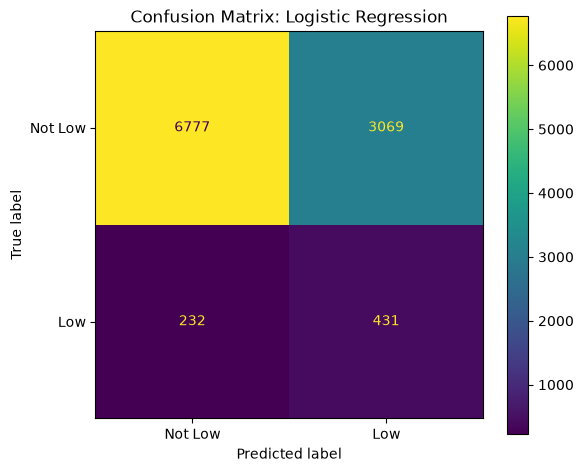

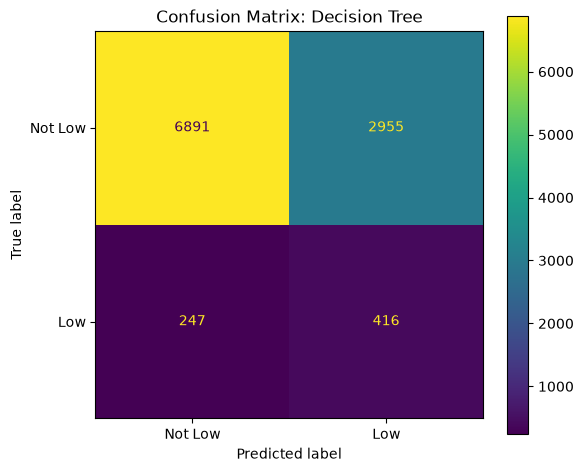

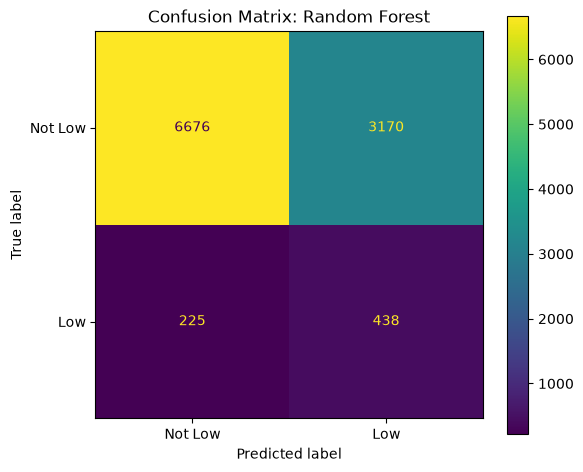

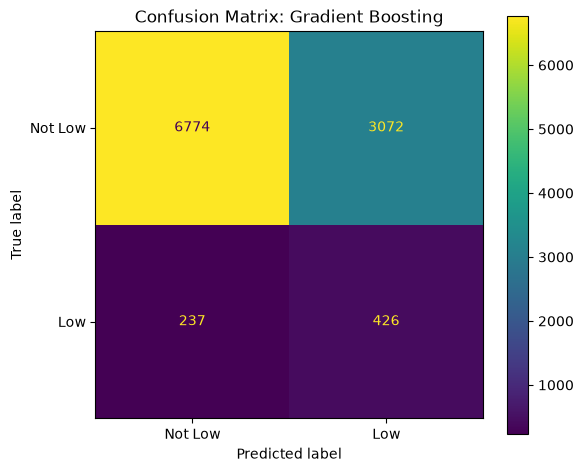

In [9]:
confusion_models = {
    "Logistic Regression": "confusion_matrix_logistic_regression.png",
    "Decision Tree": "confusion_matrix_decision_tree.png",
    "Random Forest": "confusion_matrix_random_forest.png",
    "Gradient Boosting": "confusion_matrix_gradient_boosting.png",
}

for model_name, filename in confusion_models.items():
    save_confusion_matrix(
        y_test,
        test_predictions[model_name],
        f"Confusion Matrix: {model_name}",
        filename,
    )


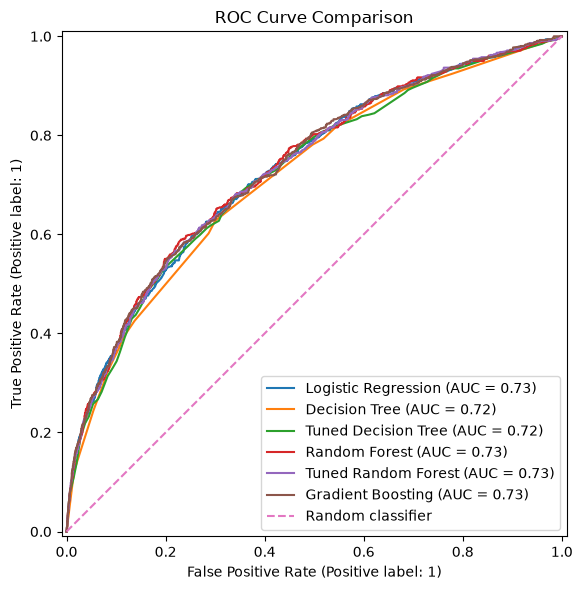

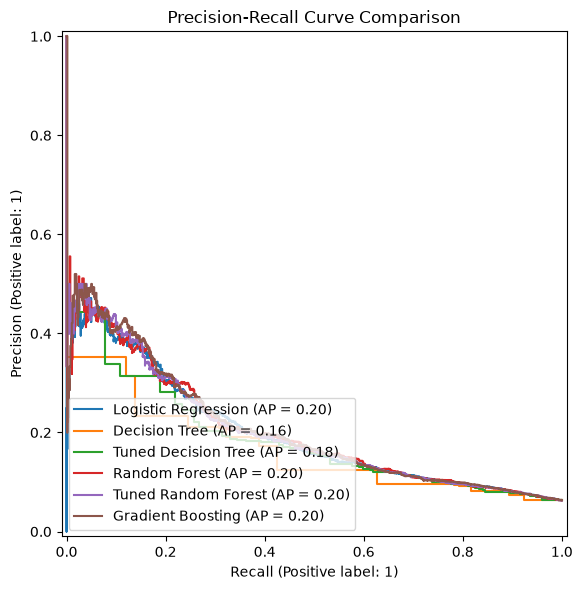

In [10]:
curve_models = [
    "Logistic Regression",
    "Decision Tree",
    "Tuned Decision Tree",
    "Random Forest",
    "Tuned Random Forest",
    "Gradient Boosting",
]

fig, ax = plt.subplots(figsize=(8, 6))
for model_name in curve_models:
    RocCurveDisplay.from_predictions(
        y_test,
        test_probabilities[model_name],
        name=model_name,
        ax=ax,
    )
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)
ax.set_title("ROC Curve Comparison")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "roc_curve_models.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for model_name in curve_models:
    PrecisionRecallDisplay.from_predictions(
        y_test,
        test_probabilities[model_name],
        name=model_name,
        ax=ax,
    )
ax.set_title("Precision-Recall Curve Comparison")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "precision_recall_curve_models.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


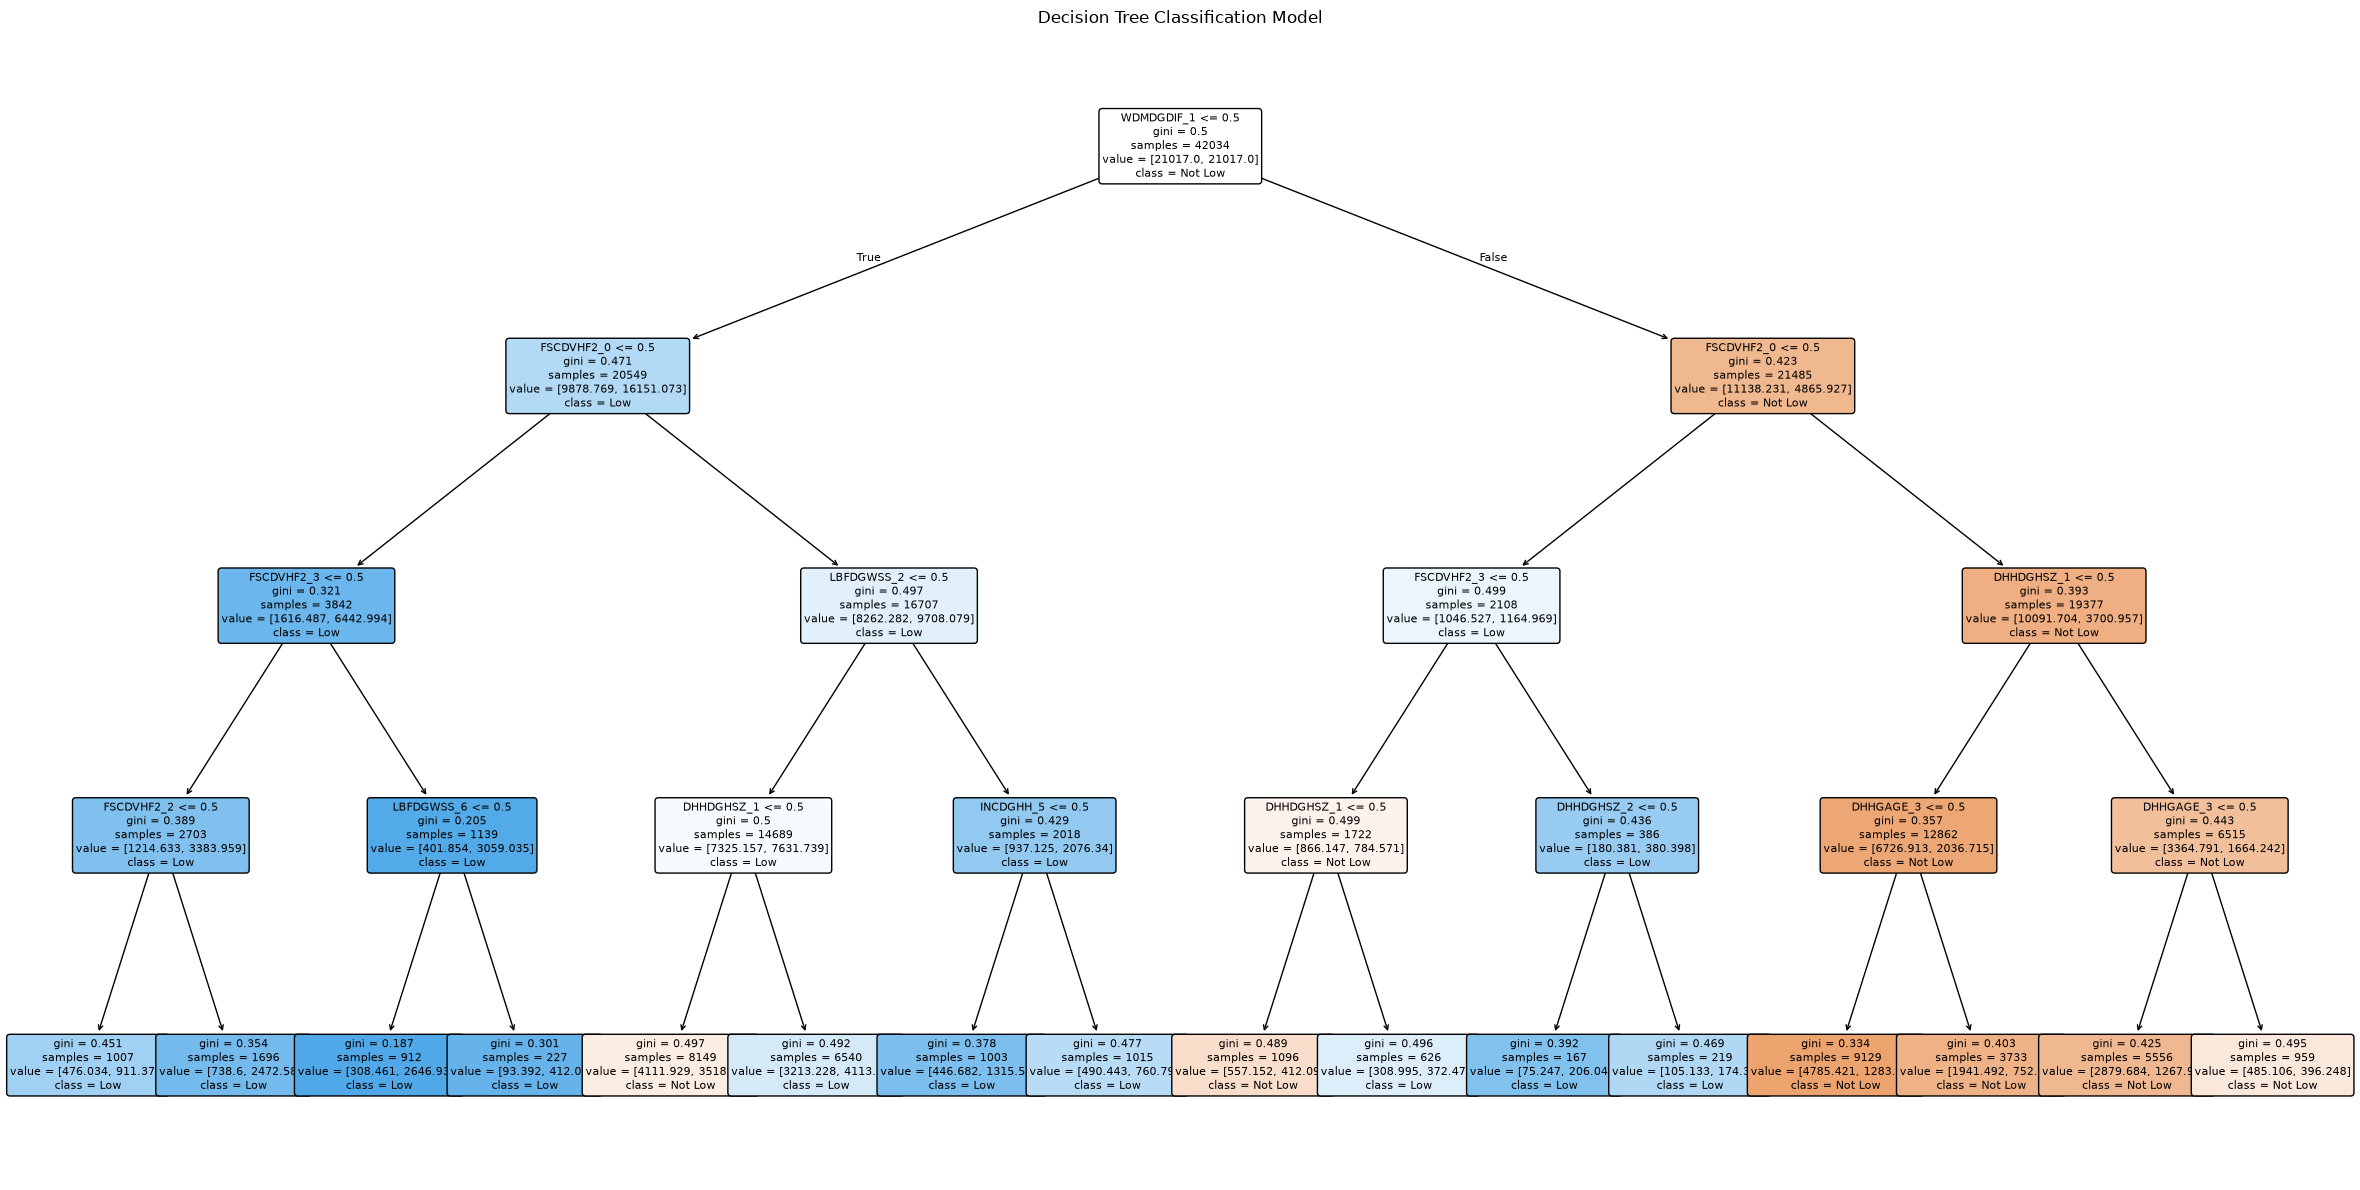

In [11]:
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=["Not Low", "Low"],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Decision Tree Classification Model")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "decision_tree_plot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 10. Tree-based feature importance


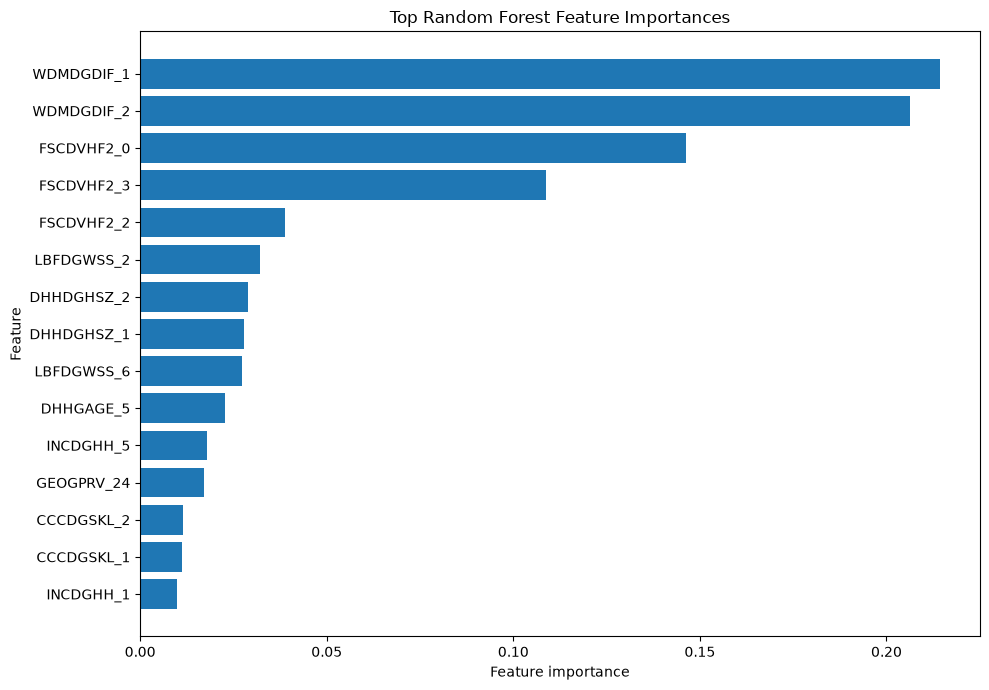

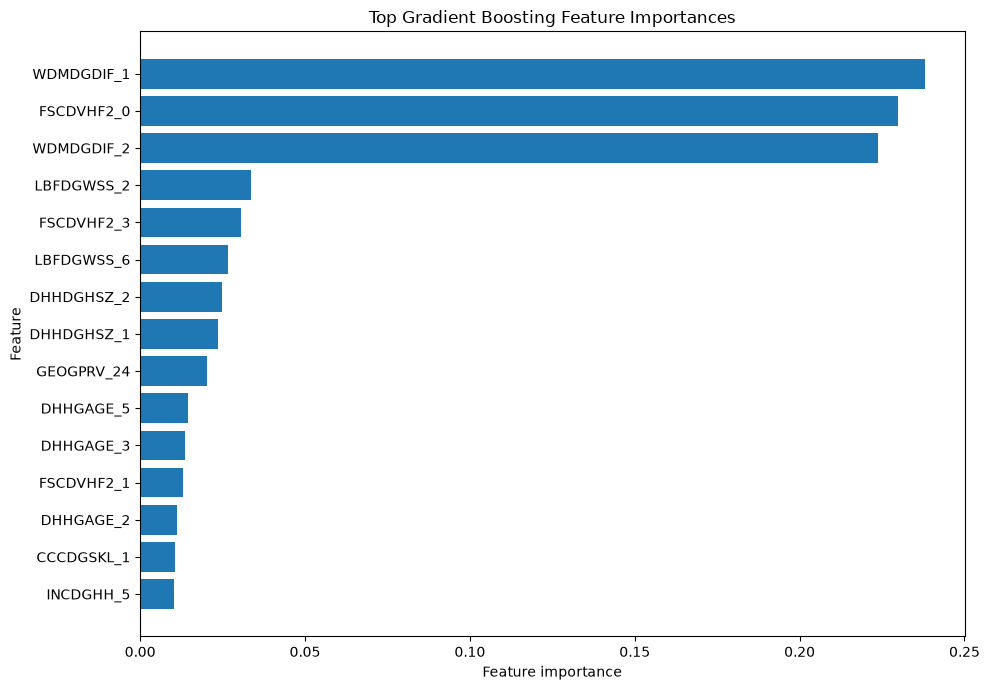

,Feature,Importance
0,WDMDGDIF_1,0.56283
1,FSCDVHF2_0,0.28421
2,LBFDGWSS_2,0.04546
3,DHHDGHSZ_1,0.04225
4,FSCDVHF2_3,0.03432
5,DHHGAGE_3,0.01341
6,INCDGHH_5,0.00796
7,FSCDVHF2_2,0.00703
8,LBFDGWSS_6,0.00158
9,DHHDGHSZ_2,0.00094


In [12]:
tree_feature_importance = create_feature_importance_table(
    decision_tree_model,
    feature_names,
)
rf_feature_importance = create_feature_importance_table(
    random_forest_model,
    feature_names,
)
gb_feature_importance = create_feature_importance_table(
    gradient_boosting_model,
    feature_names,
)

tree_feature_importance.round(5).to_csv(
    TABLE_DIR / "decision_tree_feature_importance.csv",
    index=False,
)
rf_feature_importance.round(5).to_csv(
    TABLE_DIR / "random_forest_feature_importance.csv",
    index=False,
)
gb_feature_importance.round(5).to_csv(
    TABLE_DIR / "gradient_boosting_feature_importance.csv",
    index=False,
)

save_feature_importance_plot(
    rf_feature_importance,
    "Top Random Forest Feature Importances",
    "random_forest_feature_importance.png",
)
save_feature_importance_plot(
    gb_feature_importance,
    "Top Gradient Boosting Feature Importances",
    "gradient_boosting_feature_importance.png",
)

display(tree_feature_importance.head(15).round(5))


## 11. Reference-coded Logistic Regression odds ratios

The predictive Logistic Regression remains unchanged. A separate reference-coded model is fitted for interpretation using `drop="first"`. Each odds ratio compares an encoded category with the omitted reference category for the same variable.


In [13]:
reference_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
            ),
            PREDICTORS,
        )
    ]
)

X_train_reference = reference_preprocessor.fit_transform(
    X_train
)

reference_logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE,
)
reference_logistic_model.fit(
    X_train_reference,
    y_train,
)

reference_encoder = (
    reference_preprocessor.named_transformers_["cat"]
)
reference_feature_names = [
    name.replace("cat__", "")
    for name in reference_preprocessor.get_feature_names_out()
]

reference_rows = []
coefficient_rows = []

for variable, categories, dropped_index in zip(
    PREDICTORS,
    reference_encoder.categories_,
    reference_encoder.drop_idx_,
):
    reference_category = categories[dropped_index]
    reference_rows.append({
        "Variable": variable,
        "Reference Category": reference_category,
    })

    for category_index, category in enumerate(categories):
        if category_index == dropped_index:
            continue
        coefficient_rows.append({
            "Variable": variable,
            "Category": category,
            "Reference Category": reference_category,
        })

reference_categories = pd.DataFrame(reference_rows)
reference_odds_ratios = pd.DataFrame(coefficient_rows)

if len(reference_odds_ratios) != len(
    reference_logistic_model.coef_[0]
):
    raise ValueError(
        "Reference metadata and model coefficients do not align."
    )

reference_odds_ratios["Encoded Feature"] = (
    reference_feature_names
)
reference_odds_ratios["Coefficient"] = (
    reference_logistic_model.coef_[0]
)
reference_odds_ratios["Odds Ratio"] = np.exp(
    reference_odds_ratios["Coefficient"]
)
reference_odds_ratios["Absolute Coefficient"] = (
    reference_odds_ratios["Coefficient"].abs()
)

reference_odds_ratios = reference_odds_ratios.sort_values(
    "Absolute Coefficient",
    ascending=False,
).reset_index(drop=True)

reference_categories.to_csv(
    TABLE_DIR / "logistic_regression_reference_categories.csv",
    index=False,
)
reference_odds_ratios.round(4).to_csv(
    TABLE_DIR / "logistic_regression_odds_ratios_reference_coded.csv",
    index=False,
)

display(reference_categories)
display(reference_odds_ratios.head(20).round(4))


,Variable,Reference Category
0,DHHGAGE,2
1,DHHDGHSZ,1
2,GEOGPRV,10
3,SDCDGIMM,1
4,SDCDVFLA,1
5,INCDGHH,1
6,EDDVH3,1
7,FSCDVHF2,0
8,LBFDGWSS,1
9,WDMDGDIF,1


,Variable,Category,Reference Category,Encoded Feature,Coefficient,Odds Ratio,Absolute Coefficient
0,FSCDVHF2,3,0,FSCDVHF2_3,1.5271,4.6050,1.5271
1,WDMDGDIF,2,1,WDMDGDIF_2,1.1390,3.1235,1.1390
2,FSCDVHF2,2,0,FSCDVHF2_2,0.8760,2.4013,0.8760
3,GEOGPRV,59,10,GEOGPRV_59,0.5341,1.7060,0.5341
4,DHHDGHSZ,2,1,DHHDGHSZ_2,-0.5004,0.6063,0.5004
5,GEOGPRV,35,10,GEOGPRV_35,0.4851,1.6244,0.4851
6,DHHGAGE,4,2,DHHGAGE_4,-0.4493,0.6381,0.4493
7,FSCDVHF2,1,0,FSCDVHF2_1,0.4331,1.5421,0.4331
8,LBFDGWSS,6,1,LBFDGWSS_6,-0.4030,0.6683,0.4030
9,DHHGAGE,5,2,DHHGAGE_5,-0.4030,0.6683,0.4030


### Odds-ratio interpretation note

An odds ratio above 1 indicates higher predicted odds of low life satisfaction relative to the omitted category, while an odds ratio below 1 indicates lower predicted odds, holding the other modeled predictors constant.

These estimates are predictive associations rather than causal effects. The class-weighted, regularized model is intended primarily for prediction and interpretation, not formal causal or population inference. Category-code meanings should be verified against the CCHS data dictionary.


## 12. Validation-based threshold selection

Thresholds are selected without using the test set. Five-fold out-of-fold probabilities are generated from the training data for Logistic Regression, Tuned Random Forest, and Gradient Boosting. The threshold maximizing validation F1-score is selected, with balanced accuracy used to break ties.


In [14]:
def select_rows(data, indices):
    if hasattr(data, "iloc"):
        return data.iloc[indices]
    return data[indices]


def to_dense(data):
    if hasattr(data, "toarray"):
        return data.toarray()
    return data


def generate_oof_probabilities(
    model,
    X_raw,
    y_values,
    cv,
    use_sample_weight=False,
    requires_dense=False,
):
    y_array = np.asarray(y_values)
    oof_probabilities = np.zeros(len(y_array))

    for train_index, validation_index in cv.split(
        X_raw,
        y_array,
    ):
        fold_preprocessor = clone(preprocessor)

        X_fold_train = fold_preprocessor.fit_transform(
            select_rows(X_raw, train_index)
        )
        X_fold_validation = fold_preprocessor.transform(
            select_rows(X_raw, validation_index)
        )

        if requires_dense:
            X_fold_train = to_dense(X_fold_train)
            X_fold_validation = to_dense(
                X_fold_validation
            )

        y_fold_train = y_array[train_index]
        fold_model = clone(model)

        if use_sample_weight:
            fold_weights = compute_sample_weight(
                class_weight="balanced",
                y=y_fold_train,
            )
            fold_model.fit(
                X_fold_train,
                y_fold_train,
                sample_weight=fold_weights,
            )
        else:
            fold_model.fit(
                X_fold_train,
                y_fold_train,
            )

        oof_probabilities[validation_index] = (
            fold_model.predict_proba(
                X_fold_validation
            )[:, 1]
        )

    return oof_probabilities


def threshold_metrics(
    y_true,
    probabilities,
    model_name,
):
    rows = []
    for threshold in np.round(
        np.arange(0.10, 0.91, 0.05),
        2,
    ):
        predictions = (
            probabilities >= threshold
        ).astype(int)
        rows.append({
            "Model": model_name,
            "Threshold": threshold,
            "Precision": precision_score(
                y_true,
                predictions,
                zero_division=0,
            ),
            "Recall": recall_score(
                y_true,
                predictions,
                zero_division=0,
            ),
            "F1-score": f1_score(
                y_true,
                predictions,
                zero_division=0,
            ),
            "Balanced Accuracy": balanced_accuracy_score(
                y_true,
                predictions,
            ),
        })
    return pd.DataFrame(rows)


In [15]:
threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_probabilities = {
    "Logistic Regression": generate_oof_probabilities(
        logistic_model,
        X_train,
        y_train,
        threshold_cv,
    ),
    "Tuned Random Forest": generate_oof_probabilities(
        tuned_random_forest_model,
        X_train,
        y_train,
        threshold_cv,
    ),
    "Gradient Boosting": generate_oof_probabilities(
        gradient_boosting_model,
        X_train,
        y_train,
        threshold_cv,
        use_sample_weight=True,
        requires_dense=True,
    ),
}

validation_threshold_results = pd.concat(
    [
        threshold_metrics(
            y_train,
            probabilities,
            model_name,
        )
        for model_name, probabilities
        in oof_probabilities.items()
    ],
    ignore_index=True,
)

selected_thresholds = (
    validation_threshold_results
    .sort_values(
        ["Model", "F1-score", "Balanced Accuracy"],
        ascending=[True, False, False],
    )
    .groupby("Model", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

selected_pairs = set(
    zip(
        selected_thresholds["Model"],
        selected_thresholds["Threshold"],
    )
)
validation_threshold_results["Selected"] = [
    (model, threshold) in selected_pairs
    for model, threshold in zip(
        validation_threshold_results["Model"],
        validation_threshold_results["Threshold"],
    )
]

validation_threshold_results.round(4).to_csv(
    TABLE_DIR / "threshold_tuning_validation_results.csv",
    index=False,
)

display(selected_thresholds.round(4))


,Model,Threshold,Precision,Recall,F1-score,Balanced Accuracy
0,Gradient Boosting,0.70,0.2330,0.3133,0.2672,0.6219
1,Logistic Regression,0.65,0.2063,0.4008,0.2724,0.6485
2,Tuned Random Forest,0.65,0.2354,0.3051,0.2657,0.6192


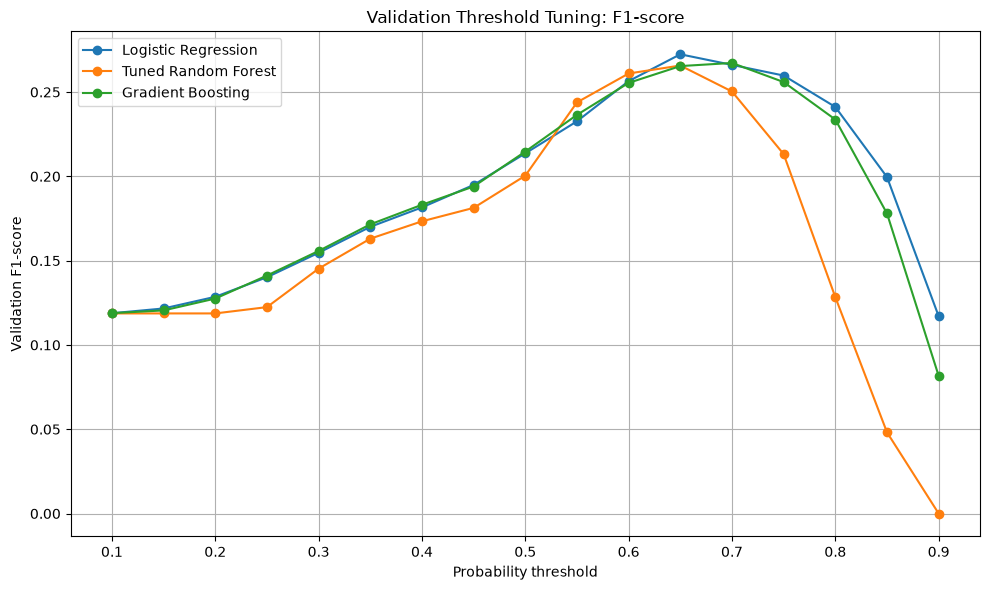

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
for model_name in validation_threshold_results[
    "Model"
].unique():
    model_data = validation_threshold_results[
        validation_threshold_results["Model"]
        == model_name
    ]
    ax.plot(
        model_data["Threshold"],
        model_data["F1-score"],
        marker="o",
        label=model_name,
    )

ax.set_title(
    "Validation Threshold Tuning: F1-score"
)
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Validation F1-score")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "threshold_tuning_validation_f1_scores.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


In [17]:
def evaluate_fixed_threshold(
    y_true,
    probabilities,
    model_name,
    threshold,
    threshold_type,
):
    predictions = (
        probabilities >= threshold
    ).astype(int)
    row = {
        "Model": model_name,
        "Threshold Type": threshold_type,
        "Threshold": threshold,
    }
    row.update(
        calculate_metrics(
            y_true,
            predictions,
            probabilities,
        )
    )
    return row


threshold_test_probabilities = {
    "Logistic Regression": test_probabilities[
        "Logistic Regression"
    ],
    "Tuned Random Forest": test_probabilities[
        "Tuned Random Forest"
    ],
    "Gradient Boosting": test_probabilities[
        "Gradient Boosting"
    ],
}

threshold_test_rows = []

for model_name, probabilities in (
    threshold_test_probabilities.items()
):
    selected_threshold = selected_thresholds.loc[
        selected_thresholds["Model"] == model_name,
        "Threshold",
    ].iloc[0]

    threshold_test_rows.append(
        evaluate_fixed_threshold(
            y_test,
            probabilities,
            model_name,
            0.50,
            "Default threshold",
        )
    )
    threshold_test_rows.append(
        evaluate_fixed_threshold(
            y_test,
            probabilities,
            model_name,
            selected_threshold,
            "Validation-selected threshold",
        )
    )

threshold_tuned_test_results = pd.DataFrame(
    threshold_test_rows
).round(4)

threshold_tuned_test_results.to_csv(
    TABLE_DIR / "threshold_tuned_test_results.csv",
    index=False,
)

display(threshold_tuned_test_results)


,Model,Threshold Type,Threshold,Accuracy,Precision,Recall,F1-score,Weighted F1-score,ROC-AUC,PR-AUC,Balanced Accuracy
0,Logistic Regression,Default threshold,0.50,0.6859,0.1231,0.6501,0.2071,0.7665,0.7307,0.1972,0.6692
1,Logistic Regression,Validation-selected threshold,0.65,0.8597,0.1930,0.3846,0.2571,0.8806,0.7307,0.1972,0.6382
2,Tuned Random Forest,Default threshold,0.50,0.6356,0.1124,0.6923,0.1933,0.7286,0.7310,0.2007,0.6620
3,Tuned Random Forest,Validation-selected threshold,0.65,0.8910,0.2249,0.2971,0.2560,0.8980,0.7310,0.2007,0.6141
4,Gradient Boosting,Default threshold,0.50,0.6851,0.1218,0.6425,0.2048,0.7659,0.7330,0.2044,0.6653
5,Gradient Boosting,Validation-selected threshold,0.70,0.8874,0.2246,0.3198,0.2638,0.8965,0.7330,0.2044,0.6227


### Threshold interpretation

The validation-selected thresholds improve precision and F1-score on the untouched test set but reduce recall relative to the default 0.50 threshold. Gradient Boosting has the highest threshold-tuned test F1-score, although the differences are small. The preferred threshold therefore depends on whether identifying more positive cases or reducing false positives is more important.


## 13. Variable-level importance comparison

Raw importance values are not directly comparable across model types. Predictor categories are aggregated to their original variables and ranked within each model. The average rank summarizes how consistently each variable appears important.


In [18]:
def aggregate_tree_importance(
    importance_table,
    output_name,
):
    table = importance_table.copy()

    def original_variable(feature):
        for variable in PREDICTORS:
            if feature.startswith(variable + "_"):
                return variable
        return feature

    table["Original Variable"] = table[
        "Feature"
    ].apply(original_variable)

    return (
        table.groupby(
            "Original Variable",
            as_index=False,
        )["Importance"]
        .sum()
        .rename(columns={
            "Importance": output_name
        })
    )


logistic_variable_importance = (
    reference_odds_ratios
    .groupby("Variable", as_index=False)
    .agg(
        Logistic_Mean_Abs_Coefficient=(
            "Absolute Coefficient",
            "mean",
        ),
        Logistic_Max_Abs_Coefficient=(
            "Absolute Coefficient",
            "max",
        ),
    )
    .rename(columns={
        "Variable": "Original Variable"
    })
)

tree_variable_importance = aggregate_tree_importance(
    tree_feature_importance,
    "Decision_Tree_Importance",
)
rf_variable_importance = aggregate_tree_importance(
    rf_feature_importance,
    "Random_Forest_Importance",
)
gb_variable_importance = aggregate_tree_importance(
    gb_feature_importance,
    "Gradient_Boosting_Importance",
)

feature_importance_comparison = (
    logistic_variable_importance
    .merge(
        tree_variable_importance,
        on="Original Variable",
        how="outer",
    )
    .merge(
        rf_variable_importance,
        on="Original Variable",
        how="outer",
    )
    .merge(
        gb_variable_importance,
        on="Original Variable",
        how="outer",
    )
    .fillna(0)
)

rank_columns = [
    "Logistic_Max_Abs_Coefficient",
    "Decision_Tree_Importance",
    "Random_Forest_Importance",
    "Gradient_Boosting_Importance",
]

for column in rank_columns:
    feature_importance_comparison[
        f"{column}_Rank"
    ] = feature_importance_comparison[
        column
    ].rank(
        ascending=False,
        method="min",
    )

feature_importance_comparison["Average_Rank"] = (
    feature_importance_comparison[
        [f"{column}_Rank" for column in rank_columns]
    ].mean(axis=1)
)

feature_importance_comparison = (
    feature_importance_comparison
    .sort_values("Average_Rank")
    .reset_index(drop=True)
)

feature_importance_comparison.round(4).to_csv(
    TABLE_DIR / "feature_importance_comparison.csv",
    index=False,
)

display(feature_importance_comparison.round(4))


,Original Variable,Logistic_Mean_Abs_Coefficient,Logistic_Max_Abs_Coefficient,Decision_Tree_Importance,Random_Forest_Importance,Gradient_Boosting_Importance,Logistic_Max_Abs_Coefficient_Rank,Decision_Tree_Importance_Rank,Random_Forest_Importance_Rank,Gradient_Boosting_Importance_Rank,Average_Rank
0,WDMDGDIF,1.1390,1.1390,0.5628,0.4207,0.4620,2.0,1.0,1.0,1.0,1.25
1,FSCDVHF2,0.9454,1.5271,0.3256,0.2989,0.2747,1.0,2.0,2.0,2.0,1.75
2,LBFDGWSS,0.3716,0.4030,0.0470,0.0674,0.0604,6.0,3.0,3.0,3.0,3.75
3,DHHDGHSZ,0.5004,0.5004,0.0432,0.0569,0.0483,4.0,4.0,4.0,5.0,4.25
4,GEOGPRV,0.2384,0.5341,0.0000,0.0336,0.0555,3.0,7.0,7.0,4.0,5.25
5,DHHGAGE,0.2944,0.4493,0.0134,0.0457,0.0434,5.0,5.0,5.0,6.0,5.25
6,INCDGHH,0.2475,0.3678,0.0080,0.0369,0.0225,7.0,6.0,6.0,7.0,6.50
7,CCCDGSKL,0.3186,0.3186,0.0000,0.0226,0.0149,8.0,7.0,8.0,8.0,7.75
8,EDDVH3,0.2142,0.2324,0.0000,0.0074,0.0069,10.0,7.0,9.0,9.0,8.75
9,SDCDGIMM,0.0164,0.0164,0.0000,0.0051,0.0062,11.0,7.0,10.0,10.0,9.50


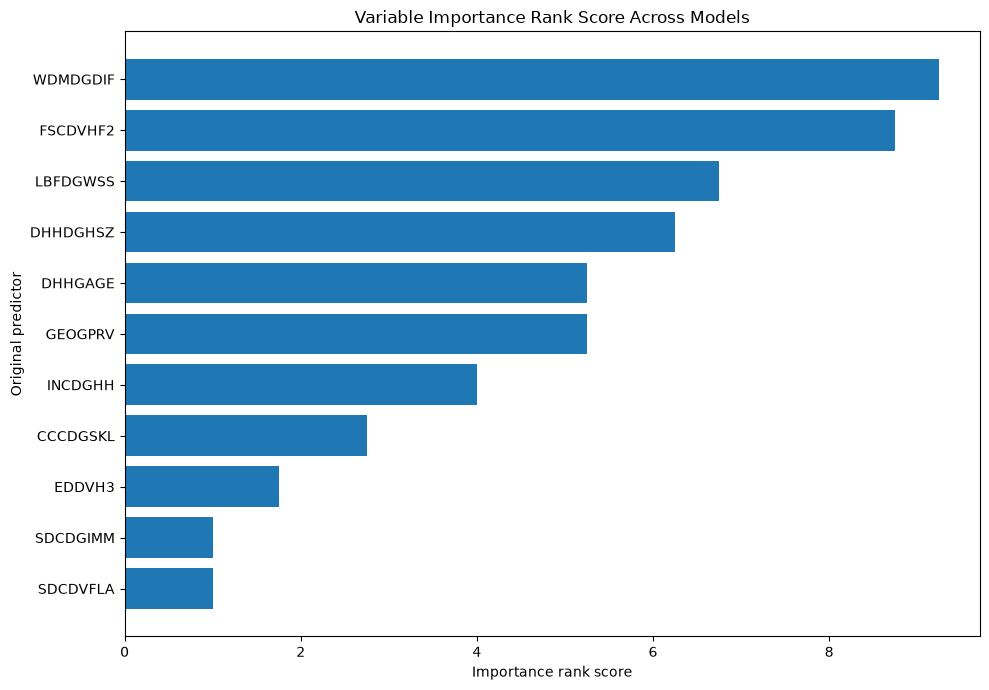

In [ ]:
rank_plot = feature_importance_comparison.copy()
max_rank = rank_plot["Average_Rank"].max()
rank_plot["Importance Rank Score"] = (
    max_rank + 1 - rank_plot["Average_Rank"]
)
rank_plot = rank_plot.sort_values(
    "Importance Rank Score"
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    rank_plot["Original Variable"],
    rank_plot["Importance Rank Score"],
)
ax.set_title(
    "Variable Importance Rank Score Across Models"
)
ax.set_xlabel("Importance rank score")
ax.set_ylabel("Original predictor")  
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "feature_importance_rank_score_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Importance interpretation

Functional difficulty (`WDMDGDIF`) and food security (`FSCDVHF2`) are the most consistently important predictors across the models, followed by labour-force/work status (`LBFDGWSS`). Household income, age, household size, province, and health-related variables contribute less consistently.

These findings represent predictive associations within the analytical sample and should not be interpreted as causal effects.


## 14. Final output check and conclusion


In [ ]:
expected_outputs = [
    TABLE_DIR / "model_performance_comparison_extended.csv",
    TABLE_DIR / "decision_tree_tuning_results.csv",
    TABLE_DIR / "random_forest_tuning_results.csv",
    TABLE_DIR / "decision_tree_feature_importance.csv",
    TABLE_DIR / "random_forest_feature_importance.csv",
    TABLE_DIR / "gradient_boosting_feature_importance.csv",
    TABLE_DIR / "logistic_regression_reference_categories.csv",
    TABLE_DIR / "logistic_regression_odds_ratios_reference_coded.csv",
    TABLE_DIR / "threshold_tuning_validation_results.csv",
    TABLE_DIR / "threshold_tuned_test_results.csv",
    TABLE_DIR / "feature_importance_comparison.csv",
    FIGURE_DIR / "confusion_matrix_logistic_regression.png",
    FIGURE_DIR / "confusion_matrix_decision_tree.png",
    FIGURE_DIR / "confusion_matrix_random_forest.png",
    FIGURE_DIR / "confusion_matrix_gradient_boosting.png",
    FIGURE_DIR / "roc_curve_models.png",
    FIGURE_DIR / "precision_recall_curve_models.png",
    FIGURE_DIR / "decision_tree_plot.png",
    FIGURE_DIR / "random_forest_feature_importance.png",
    FIGURE_DIR / "gradient_boosting_feature_importance.png",
    FIGURE_DIR / "threshold_tuning_validation_f1_scores.png",
    FIGURE_DIR / "feature_importance_rank_score_comparison.png",
]

output_check = pd.DataFrame({
    "Output": [str(path) for path in expected_outputs],
    "Exists": [path.exists() for path in expected_outputs],  
})

display(output_check)


,Output,Exists
0,..\outputs\tables\model_performance_comparison...,True
1,..\outputs\tables\decision_tree_tuning_results...,True
2,..\outputs\tables\random_forest_tuning_results...,True
3,..\outputs\tables\decision_tree_feature_import...,True
4,..\outputs\tables\random_forest_feature_import...,True
5,..\outputs\tables\gradient_boosting_feature_im...,True
6,..\outputs\tables\logistic_regression_referenc...,True
7,..\outputs\tables\logistic_regression_odds_rat...,True
8,..\outputs\tables\threshold_tuning_validation_...,True
9,..\outputs\tables\threshold_tuned_test_results...,True


## Final predictive modeling conclusion

All non-baseline models perform substantially better than the majority-class baseline for identifying low life satisfaction, although overall predictive performance is moderate.

Gradient Boosting produces the highest PR-AUC in the held-out test set, but its improvement over Logistic Regression and Random Forest is small. The more complex models do not dramatically outperform Logistic Regression, supporting its retention as an important interpretable model.

Functional difficulty, food security, and labour-force/work status are the most consistent predictors across models. The results are unweighted, describe predictive associations within the analytical sample, and are neither causal nor nationally representative.
